In [10]:
print("hi")

hi


In [13]:
print("hi")

hi


In [15]:
print("hi")

hi


In [14]:
print("hi")

hi



==================== Logistic Regression Metrics ====================
Accuracy  : 0.5750
Precision : 0.5397
Recall    : 0.5750
F1 Score  : 0.5188

==================== Confusion Matrix ====================
       0      1      2     3    4     5
0  91341  11663     13  1167   16  1250
1  23030  19097      0     0    0    73
2  14155      0  13327     0    0     0
3  12890   5798      0  1561    0    12
4  12263    697   4392    38    0   138
5   6871    210     29     1  148  3016



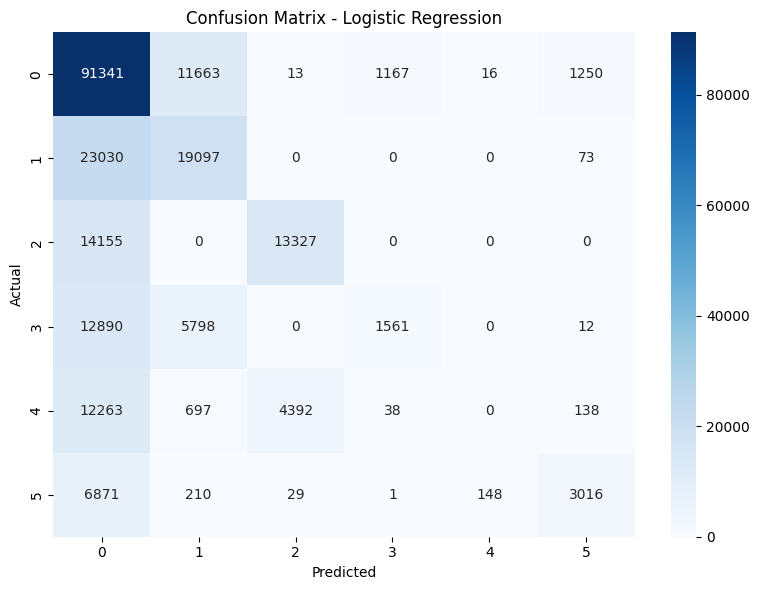

✔ Logistic Regression complete – all outputs saved to /kaggle/working/


In [12]:
# ================================================================
# Logistic Regression - PySpark Model + Sklearn Metrics
# ================================================================

from pyspark.sql import SparkSession
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

spark = SparkSession.builder.getOrCreate()

# ------------------------------------------------------------
# 1. Load CSV
# ------------------------------------------------------------
df = spark.read.csv(
    "/kaggle/input/mqtt-processed/part-00000-7b22535d-495b-4742-b4ee-112f08e809b0-c000.csv",
    header=True,
    inferSchema=True
).dropna()

# ------------------------------------------------------------
# 2. Features & Label
# ------------------------------------------------------------
label_col = "label_idx"

numeric_cols = [  
 'f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5',
    'f_6', 'f_7', 'f_8', 'f_9', 'f_10', 'f_11'
]

assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)

pipeline = Pipeline(stages=[assembler, scaler])
processed_df = pipeline.fit(df).transform(df)

processed_df.write.mode("overwrite").parquet("/kaggle/working/MQTT_processed.parquet")

# ------------------------------------------------------------
# 3. Train/Test split
# ------------------------------------------------------------
train_df, test_df = processed_df.randomSplit([0.8, 0.2], seed=42)

# ------------------------------------------------------------
# 4. Logistic Regression model (PySpark)
# ------------------------------------------------------------
lr = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="label_idx",
    maxIter=200,
    regParam=0.01,
    elasticNetParam=0.0
)

lr_model = lr.fit(train_df)

# ------------------------------------------------------------
# 5. Predictions (PySpark)
# ------------------------------------------------------------
pred_lr = lr_model.transform(test_df).select("label_idx", "prediction")
pred_lr_pd = pred_lr.toPandas()  # Convert to pandas for sklearn metrics

y_true = pred_lr_pd["label_idx"]
y_pred = pred_lr_pd["prediction"]

# ------------------------------------------------------------
# 6. SKLEARN METRICS (Accuracy, Precision, Recall, F1)
# ------------------------------------------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

# Print metrics
print("\n==================== Logistic Regression Metrics ====================")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("=====================================================================\n")

# Save metrics
pd.DataFrame([{
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}]).to_csv("/kaggle/working/metrics_lr.csv", index=False)

# ------------------------------------------------------------
# 7. CONFUSION MATRIX (SKLEARN)
# ------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm)
cm_df.to_csv("/kaggle/working/confusion_lr.csv", index=False)

print("==================== Confusion Matrix ====================")
print(cm_df)
print("===========================================================\n")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_lr.png")
plt.show()

# ------------------------------------------------------------
# 8. Save Model (PySpark)
# ------------------------------------------------------------
lr_model.write().overwrite().save("/kaggle/working/lr_model")

print("✔ Logistic Regression complete – all outputs saved to /kaggle/working/")
